# Preguntas de negocio

### 1. ¿Cuál es el impacto real de nuestra política de descuentos en el volumen de ventas?
* __Valor de negocio__: En MedTech, los ejecutivos de cuenta suelen dar descuentos para cerrar ventas, pero a veces esto solo erosiona el margen sin generar un aumento real en la adopción del producto. Necesitamos saber si "baratear" el equipo realmente funciona.
* __Concepto estadístico__: Correlación y Regresión Lineal Simple. No nos quedaremos con un simple gráfico de dispersión. Calcularemos el Coeficiente de Correlación de Pearson ($r$) entre Discount_Applied y Quantity. Si existe correlación, plantearemos un modelo de regresión para estimar matemáticamente cuánto volumen extra genera cada punto porcentual de descuento, validando si el resultado es estadísticamente significativo a través de su $p-value$.

### 2. ¿Existen diferencias significativas en el ticket promedio de compra entre hospitales públicos y privados?
* __Valor de negocio__: Esto dicta hacia dónde dirigir el presupuesto de marketing y el esfuerzo de la fuerza de ventas. Si un sector gasta significativamente más, la estrategia de penetración debe ajustarse.
* __Concepto estadístico__: Prueba de Hipótesis (T-test para muestras independientes). Formularemos una hipótesis nula ($H_0$): "No hay diferencia en la media de ventas entre hospitales públicos y privados". Usaremos estadística inferencial para probar o rechazar esto con un nivel de confianza del 95% ($\alpha = 0.05$), demostrando que la diferencia no es producto del azar (ruido en los datos).

### 3. ¿Qué regiones o categorías de productos presentan anomalías severas en sus ventas (Outliers)?
* __Valor de negocio__: Un pico irreal de ventas puede ser un error de captura, fraude, o un éxito masivo temporal (ej. una licitación de gobierno). Identificarlos es vital para limpiar la proyección financiera.
* __Concepto estadístico__: Detección de valores atípicos (Outliers). Aplicaremos la regla del Rango Intercuartílico (IQR) y el cálculo de Z-scores ($Z = \frac{x - \mu}{\sigma}$). En el pipeline de limpieza, identificaremos matemáticamente qué transacciones se alejan más de 3 desviaciones estándar de la media para tratarlas antes de que ensucien el dashboard de Power BI.

### 4. ¿La satisfacción del cliente está ligada al volumen de equipos de imagenología adquiridos?
* __Valor de negocio__: Los equipos como tomógrafos o resonancias magnéticas requieren mantenimiento y servicio postventa. Queremos saber si una mala calificación de satisfacción nos está costando futuras compras de alto valor.
* __Concepto estadístico__: Análisis de Varianza (ANOVA) o Chi-Cuadrada. Primero aplicaremos técnicas de Imputación de Datos (como usar la media o mediana, o un modelo predictivo simple). Luego, dividiremos la satisfacción en categorías (Baja, Media, Alta) y aplicaremos ANOVA para ver si la varianza en las ventas de imagenología se explica por el nivel de satisfacción.

### 5. ¿Cuál es el comportamiento estacional y la tendencia de los productos consumibles frente a los quirúrgicos?
* __Valor de negocio__: Los consumibles (jeringas, gasas) deberían tener un flujo constante, mientras que los equipos quirúrgicos son compras esporádicas. Entender esta curva permite optimizar la cadena de suministro y evitar desabasto (stockouts) en el almacén.
* __Concepto estadístico__: Análisis de Series de Tiempo (Descomposición). Separaremos los datos en sus componentes fundamentales: tendencia (dirección a largo plazo), estacionalidad (patrones repetitivos) y ruido (variación aleatoria). Aplicaremos promedios móviles para suavizar las curvas de demanda y poder visualizar el verdadero comportamiento del mercado.

In [1]:
pip install pingouin

Note: you may need to restart the kernel to use updated packages.


In [120]:
# importación de librerías 
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.seasonal import seasonal_decompose
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# Carga de datos 

df = pd.read_csv("../data/raw/medtech_sales_data.csv")
df.head()

,Order_ID,Date,Hospital_Type,Region,Product_Category,Product_Name,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
0,ORD-3032,2023-01-01,Privado,Sur,Consumibles,Jeringas 5ml,492,14.00,0.06,6474.72,8.7
1,ORD-5157,2023-01-01,Privado,Centro,Consumibles,Guantes de Nitrilo,512,16.72,0.02,8389.43,8.8
2,ORD-4246,2023-01-01,Público,Norte,Consumibles,Guantes de Nitrilo,528,15.88,0.02,8216.95,6.8
3,ORD-4047,2023-01-01,Público,Occidente,Quirúrgicos,Bisturí Ultrasónico,5,4582.19,0.04,21994.51,10.0
4,ORD-2137,2023-01-01,Público,Occidente,Consumibles,Catéteres,554,15.21,0.04,8089.29,NaN


In [4]:
df['Product_Category'].unique()

<StringArray>
['Consumibles', 'Quirúrgicos', 'Imagenología']
Length: 3, dtype: str

In [5]:
df[df['Product_Category'] == 'Consumibles'].describe()

,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
count,3488.000000,3488.000000,3488.000000,3488.000000,2797.000000
mean,611.154530,15.005272,0.030049,7274.243048,7.931319
std,2322.475974,2.005051,0.027391,1047.075635,1.391911
min,428.000000,7.780000,0.000000,4008.410000,2.600000
25%,484.000000,13.660000,0.010000,6552.457500,7.000000
50%,500.000000,14.970000,0.020000,7265.445000,8.000000
75%,515.000000,16.350000,0.040000,7991.462500,9.000000
max,50100.000000,23.300000,0.170000,11533.500000,10.000000


In [6]:
df[df['Product_Category'] == 'Quirúrgicos'].describe()

,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
count,1011.000000,1011.000000,1011.000000,1011.000000,803.000000
mean,5.506429,4990.636775,0.030653,24289.670554,7.941968
std,15.730109,499.619958,0.027618,11284.844317,1.416801
min,1.000000,3396.550000,0.000000,3617.960000,3.300000
25%,3.000000,4634.190000,0.010000,16368.725000,7.000000
50%,5.000000,4994.820000,0.020000,22924.980000,8.000000
75%,6.000000,5313.555000,0.040000,31306.630000,9.000000
max,500.000000,6725.280000,0.170000,68148.010000,10.000000


In [7]:
df[df['Product_Category'] == 'Imagenología'].describe()

,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
count,501.000000,501.000000,501.000000,5.010000e+02,400.000000
mean,2.520958,149038.590080,0.030180,2.797183e+05,7.895500
std,13.355675,20027.431934,0.028757,1.590763e+05,1.350422
min,1.000000,97332.680000,0.000000,8.954607e+04,3.500000
25%,1.000000,135961.920000,0.010000,1.491563e+05,7.000000
50%,2.000000,148883.570000,0.020000,2.634258e+05,8.000000
75%,2.000000,162732.850000,0.040000,3.484439e+05,8.900000
max,300.000000,217436.420000,0.180000,1.365797e+06,10.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               5000 non-null   str    
 1   Date                   5000 non-null   str    
 2   Hospital_Type          5000 non-null   str    
 3   Region                 4750 non-null   str    
 4   Product_Category       5000 non-null   str    
 5   Product_Name           5000 non-null   str    
 6   Quantity               5000 non-null   int64  
 7   Unit_Price_USD         5000 non-null   float64
 8   Discount_Applied       5000 non-null   float64
 9   Total_Sales_USD        5000 non-null   float64
 10  Customer_Satisfaction  4000 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 429.8 KB


**Nota:** 

Region y Customer_Satisfatcion tienen datos faltantes

In [9]:
# Limpieza de outliers 
z_scores = np.abs(stats.zscore(df['Quantity']))
df_clean = df[z_scores < 3].copy()
print(f"Registros preservados después de limpiar outliers: {len(df_clean)}")

Registros preservados después de limpiar outliers: 4992


In [10]:
# Corrección de datos faltantas 

    # Región
df_clean['Region'] = df_clean['Region'].fillna("Desconocido")

    # Satisfacción de clientes
median_satisfaction = df_clean['Customer_Satisfaction'].median()
df_clean['Customer_Satisfaction'] = df_clean['Customer_Satisfaction'].fillna(median_satisfaction)

df_clean.info()

<class 'pandas.DataFrame'>
Index: 4992 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               4992 non-null   str    
 1   Date                   4992 non-null   str    
 2   Hospital_Type          4992 non-null   str    
 3   Region                 4992 non-null   str    
 4   Product_Category       4992 non-null   str    
 5   Product_Name           4992 non-null   str    
 6   Quantity               4992 non-null   int64  
 7   Unit_Price_USD         4992 non-null   float64
 8   Discount_Applied       4992 non-null   float64
 9   Total_Sales_USD        4992 non-null   float64
 10  Customer_Satisfaction  4992 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 468.0 KB


**Nota** 

Se eliminaron 8 registros después de la limpieza de outliers; no se tienen más datos null en el dataframe. 

In [11]:
# Correlación entre descuento y volumen de venta 
corr, p_value_corr = stats.pearsonr(df_clean['Discount_Applied'], df_clean['Quantity'])
print(f"Coeficiente de correlación(r): {corr:.2f}")
print(f"P valor : {p_value_corr:.2f}")

Coeficiente de correlación(r): -0.01
P valor : 0.66


**Nota** 

No se muestra una relación entre los descuentos aplicados y el volúmen de compra. Se debe revisar si existe diferencia en la correlación para diferentes segmentos de clientes. 

Tipo de cliente: Privado

- Coeficiente pearson: -0.01

- P-value: 0.84

 * Resultado no significativo

Tipo de cliente: Público

- Coeficiente pearson: 0.01

- P-value: 0.75

 * Resultado no significativo

Tipo de cliente: Clínica Especializada

- Coeficiente pearson: -0.04

- P-value: 0.20

 * Resultado no significativo



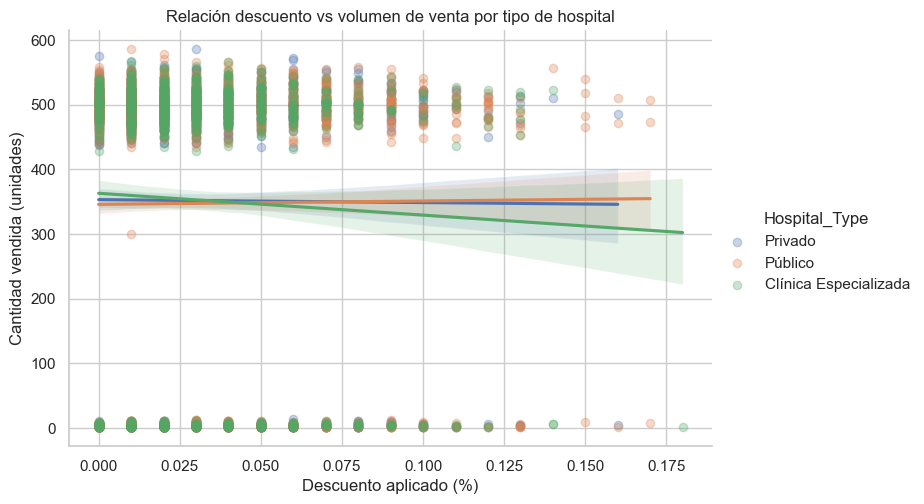

In [12]:
# Correlación para otros segmentos de mercado

for h_type in df_clean['Hospital_Type'].unique():
    subset = df_clean[df_clean['Hospital_Type'] == h_type]
    r, p_value_corr = stats.pearsonr(subset['Discount_Applied'], subset['Quantity'])
    print(f"Tipo de cliente: {h_type}")
    print(f"\n- Coeficiente pearson: {r:.2f}")
    print(f"\n- P-value: {p_value_corr:.2f}")

    if p_value_corr < 0.05:
        print("\n * Resultado estadístico significativa")
    else:
        print("\n * Resultado no significativo\n")



# Visualización de tendencia 
sns.set_theme(style = 'whitegrid')
g = sns.lmplot(
    data = df_clean, 
    x = 'Discount_Applied', 
    y= 'Quantity', 
    hue = 'Hospital_Type',
    height= 5, 
    aspect= 1.5, 
    scatter_kws={'alpha': 0.3}
)

g.set_axis_labels("Descuento aplicado (%)", "Cantidad vendida (unidades)")
plt.title("Relación descuento vs volumen de venta por tipo de hospital")
plt.show()


*Nota:*

No hay correlación entre el descuento aplicado y el volumen de venta para los segmentos de clientes. 

In [13]:
# Comparación del ticket promedio de hospítal público vs privado 

ventas_publico = df_clean[df_clean['Hospital_Type']== 'Público']['Total_Sales_USD']
ventas_privado = df_clean[df_clean['Hospital_Type']== 'Privado']['Total_Sales_USD']

t_stat, p_value_t = stats.ttest_ind(ventas_publico, ventas_privado, equal_var = False)

if p_value_t < 0.05:
    print(f"Existe una diferencia estadística significativa entre las medias de venta a hospital público: {ventas_publico.mean():.2f} y venta a hospital privado {ventas_privado.mean():.2f}")
    print(f"Estadístico T= {t_stat:.2f} | P-valor ={p_value_t:.2f}")
else:
    print(f"No existe una diferencia estadística significativa entre las medias de venta a hospital público: {ventas_publico.mean():.2f} y venta a hospital privado {ventas_privado.mean():.2f}")
    print(f"Estadístico T= {t_stat:.2f} | P-valor ={p_value_t:.2f}")

No existe una diferencia estadística significativa entre las medias de venta a hospital público: 37653.98 y venta a hospital privado 37776.44
Estadístico T= -0.04 | P-valor =0.97


In [14]:
# Compración del ticket promedio entre los diferente tipos de hosptiales en el dataset 

# Se usa ANOVA y post-hoc la prueba de Tukey y Games-Howell (asume heterocedasticidad)
grupos = [df_clean[df_clean['Hospital_Type'] == h]['Total_Sales_USD'] for h in df_clean['Hospital_Type'].unique()]

f_stat, p_value_anova = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.2f}")
print(f"Valor P ANOVA: {p_value_anova:.2f}")

Estadístico F: 0.15
Valor P ANOVA: 0.86


In [15]:
# Prueba de Tukey (se asume homocedasticidad)

tukey = pairwise_tukeyhsd(
    endog= df_clean['Total_Sales_USD'], 
    groups= df_clean['Hospital_Type'], 
    alpha = 0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
        group1         group2  meandiff  p-adj     lower      upper   reject
----------------------------------------------------------------------------
Clínica Especializada Privado -1745.4412 0.8958 -10901.5583 7410.6759  False
Clínica Especializada Público -1867.8984 0.8609 -10268.2365 6532.4397  False
              Privado Público  -122.4572 0.9992  -7435.2182 7190.3038  False
----------------------------------------------------------------------------


In [16]:
# Prueba de Games-Howell (se asume heterocedasticidad)
gh_test = pg.pairwise_gameshowell(
    data = df_clean, 
    dv = 'Total_Sales_USD', 
    between = 'Hospital_Type'
)

print(gh_test)

                       A        B        mean_A        mean_B         diff  \
0  Clínica Especializada  Privado  39521.882354  37776.441144  1745.441210   
1  Clínica Especializada  Público  39521.882354  37653.983960  1867.898394   
2                Privado  Público  37776.441144  37653.983960   122.457184   

            se         T           df      pval    hedges  
0  4099.487915  0.425771  2061.593619  0.904926  0.017555  
1  3716.992601  0.502529  1664.099849  0.870102  0.019741  
2  3114.647076  0.039317  3004.604214  0.999148  0.001304  


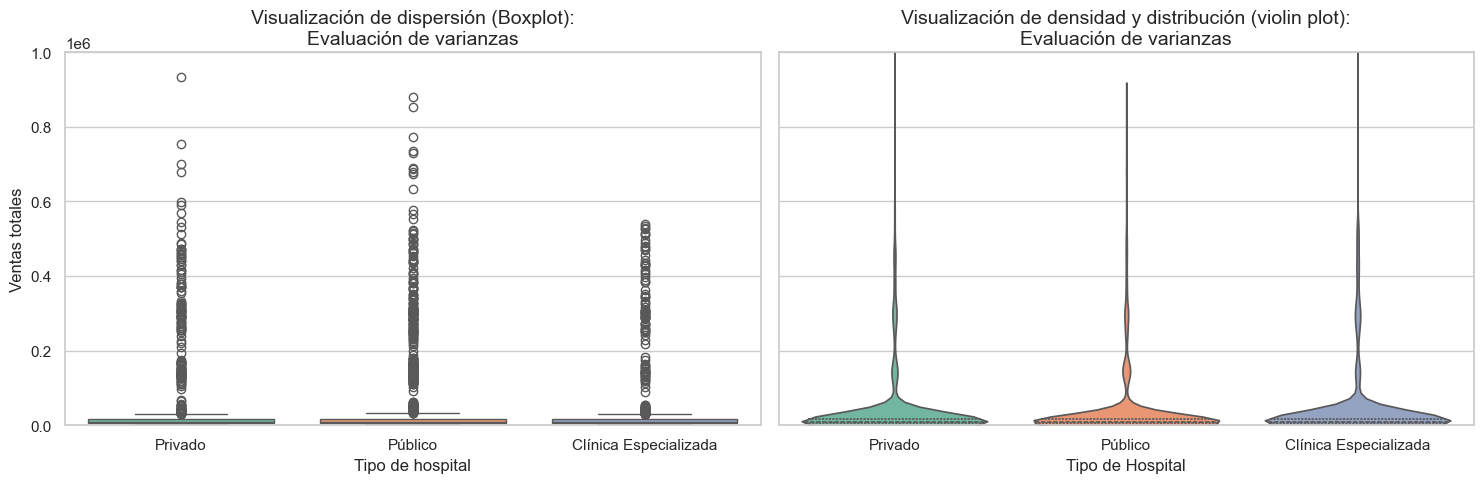

In [17]:
# Demostración gráfica de diferencia entre las varianzas 

sns.set_theme(style = 'whitegrid')

fig, (ax1, ax2) = plt.subplots(1,2,figsize = (15,5), sharey= True)

sns.boxplot(
    data = df_clean,
    x = 'Hospital_Type', 
    y = 'Total_Sales_USD', 
    hue = 'Hospital_Type',
    palette = 'Set2', 
    ax = ax1
)

ax1.set_title('Visualización de dispersión (Boxplot):\nEvaluación de varianzas', fontsize=14)
ax1.set_xlabel('Tipo de hospital', fontsize = 12)
ax1.set_ylabel('Ventas totales', fontsize = 12)
ax1.set_ylim(bottom= 0 , top = 1000000)

sns.violinplot(
    data = df_clean, 
    x = 'Hospital_Type',
    y = 'Total_Sales_USD', 
    palette = 'Set2',
    hue = 'Hospital_Type',
    inner = 'quartile'
)

ax2.set_title('Visualización de densidad y distribución (violin plot):\nEvaluación de varianzas', fontsize=14)
ax2.set_xlabel('Tipo de Hospital', fontsize=12)
ax2.set_ylabel('Ventas Totales (USD)', fontsize=12)

plt.tight_layout()
plt.show()


Text(0.5, 0, 'Tipo de Hospital')

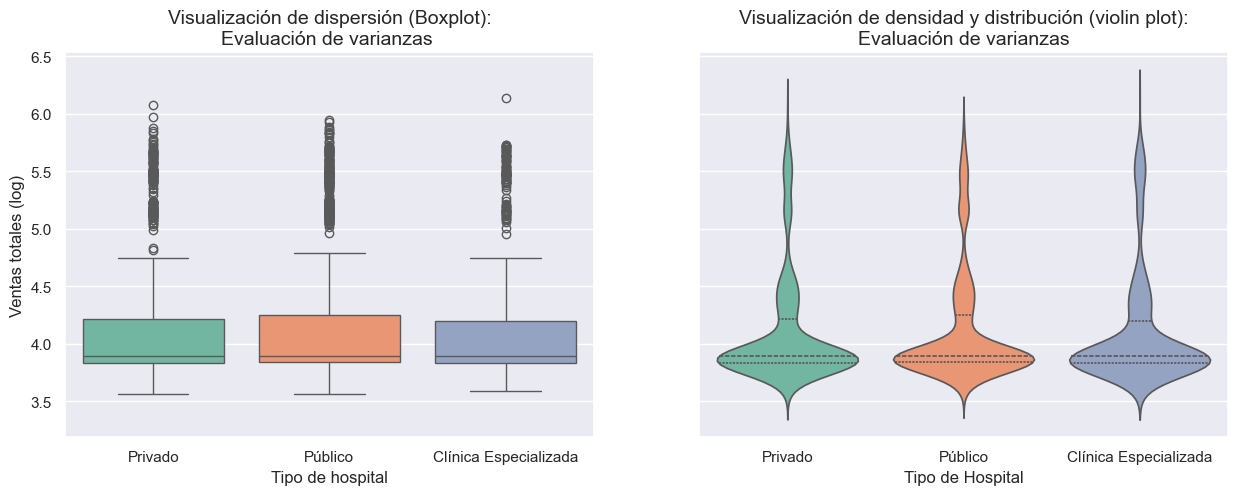

In [18]:
# Aplicación de escala logaritmica en el eje y para ver mejor la distribución 
df_log = df_clean.copy()

df_log['Sales_log'] = np.log10(df_log['Total_Sales_USD'])

sns.set_theme(style = 'darkgrid')

fig, (ax1, ax2) = plt.subplots(1,2,figsize = (15,5), sharey= True)

sns.boxplot(
    data = df_log,
    x = 'Hospital_Type', 
    y = 'Sales_log', 
    hue = 'Hospital_Type',
    palette = 'Set2', 
    ax = ax1
)

ax1.set_title('Visualización de dispersión (Boxplot):\nEvaluación de varianzas ', fontsize=14)
ax1.set_xlabel('Tipo de hospital', fontsize = 12)
ax1.set_ylabel('Ventas totales (log)', fontsize = 12)

sns.violinplot(
    data = df_log, 
    x = 'Hospital_Type',
    y = 'Sales_log', 
    palette = 'Set2',
    hue = 'Hospital_Type',
    inner = 'quartile'
)

ax2.set_title('Visualización de densidad y distribución (violin plot):\nEvaluación de varianzas', fontsize=14)
ax2.set_xlabel('Tipo de Hospital', fontsize=12)

In [19]:
# Definición de lógica de segmentación de ventas para los dos tipos de productos 'Consumible alto volumen' | 'Equipos_medicos'

def segmentador(categoria):
  if categoria == 'Consumibles':
       return 'Consumible alto volumen'
  else:
       return 'Equipo medico alto valor'

df_clean['Business_unit'] = df_clean['Product_Category'].map(segmentador)

df_clean.sample(10)

,Order_ID,Date,Hospital_Type,Region,Product_Category,Product_Name,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction,Business_unit
4497,ORD-5637,2024-10-20,Público,Bajío,Consumibles,Gasas Estériles,530,16.26,0.00,8617.80,7.8,Consumible alto volumen
1810,ORD-3085,2023-09-24,Privado,Centro,Quirúrgicos,Bisturí Ultrasónico,3,5313.93,0.06,14985.28,8.0,Equipo medico alto valor
272,ORD-1115,2023-02-10,Público,Norte,Consumibles,Gasas Estériles,482,14.87,0.02,7023.99,10.0,Consumible alto volumen
2798,ORD-3640,2024-02-17,Público,Occidente,Consumibles,Jeringas 5ml,505,13.77,0.02,6814.77,9.7,Consumible alto volumen
2005,ORD-5907,2023-10-23,Clínica Especializada,Occidente,Consumibles,Catéteres,500,14.02,0.02,6869.80,9.9,Consumible alto volumen
2790,ORD-4865,2024-02-16,Público,Norte,Consumibles,Catéteres,514,16.95,0.03,8450.93,8.0,Consumible alto volumen
2424,ORD-2643,2023-12-26,Privado,Sur,Consumibles,Guantes de Nitrilo,498,18.12,0.00,9023.76,7.5,Consumible alto volumen
168,ORD-1480,2023-01-23,Público,Bajío,Consumibles,Catéteres,471,14.92,0.00,7027.32,7.9,Consumible alto volumen
2047,ORD-4713,2023-10-30,Privado,Norte,Consumibles,Jeringas 5ml,522,15.33,0.01,7922.24,9.4,Consumible alto volumen
2120,ORD-5406,2023-11-10,Privado,Centro,Quirúrgicos,Lámpara Cialítica,14,5178.42,0.06,68148.01,8.0,Equipo medico alto valor


In [20]:
# Alternativo con diccionario 

"""seg__map = {
    'Consumibles' : 'Consumible alto volumne', 
    'Quirúrgicos' : 'Equipo medico alto valor', 
    'Imagenología': 'Imagenología'
}


df_clean['Business_unit'] = df_clean['Product_Category'].map(seg__map)"""


"seg__map = {\n    'Consumibles' : 'Consumible alto volumne', \n    'Quirúrgicos' : 'Equipo medico alto valor', \n    'Imagenología': 'Imagenología'\n}\n\n\ndf_clean['Business_unit'] = df_clean['Product_Category'].map(seg__map)"

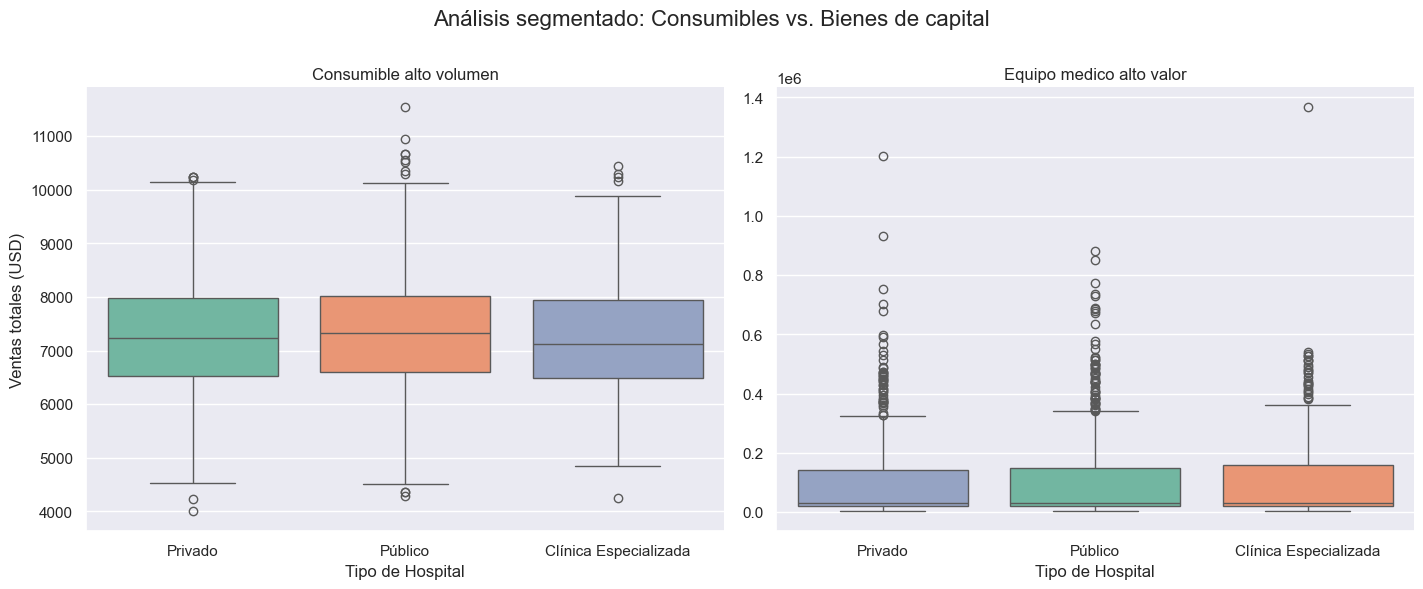

In [109]:
# Gráica con FacetGrid boxplot 

g = sns.FacetGrid(df_clean, col="Business_unit", sharey=False, sharex=False, height=6, aspect=1.2)
g.map_dataframe(
    sns.boxplot, 
    x='Hospital_Type', 
    y='Total_Sales_USD', 
    hue = 'Hospital_Type',
    palette='Set2',
    order = ['Privado', 'Público', 'Clínica Especializada']
    )

# Ajustes estéticos
g.set_axis_labels("Tipo de Hospital", "Ventas totales (USD)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Análisis segmentado: Consumibles vs. Bienes de capital', fontsize=16)
plt.show()

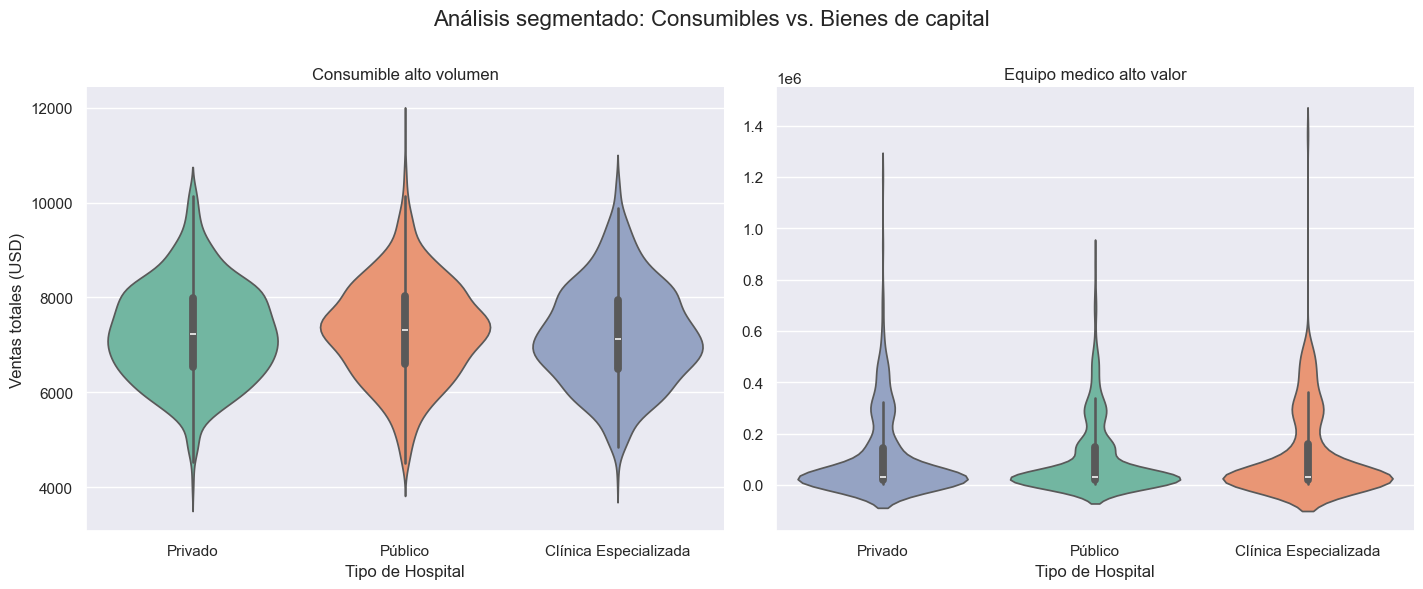

In [22]:


g = sns.FacetGrid(df_clean, col="Business_unit", sharey=False, sharex=False, height=6, aspect=1.2)
g.map_dataframe(
    sns.violinplot, 
    x='Hospital_Type', 
    y='Total_Sales_USD', 
    hue = 'Hospital_Type',
    palette='Set2',
    order = ['Privado', 'Público', 'Clínica Especializada']
    )

# Ajustes estéticos
g.set_axis_labels("Tipo de Hospital", "Ventas totales (USD)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Análisis segmentado: Consumibles vs. Bienes de capital', fontsize=16)
plt.show()

*Nota:*

Cuando se segmentan las ventas por Business_unit se observa que la varianza es homogénea. Pero ya se había mencaiondo que no hay diferencia estadística significativa entre los tickets medios entre los diferentes tipos de hospital. 

In [23]:
# Detección de regiones con ventas muy altas, sujetas a investigación para ver si son legitimas, licitaciones ganadas, o fraudes

def detect_zcore_outliers(data, column, threshold = 3):

    z_scores = np.abs(stats.zscore(data[column]))

    return data[z_scores < threshold]



def detect_iqr_outliers(data, group_col, target_col):

    outliers_list = []

    for group in data[group_col].unique():
        subset = data[data[group_col] == group]
        q1 = subset[target_col].quantile(0.25)
        q3 = subset[target_col].quantile(0.75)
        IQR = q3 - q1 

        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR 

        anomalias = subset[(subset[target_col] < lower_bound)|(subset[target_col] > upper_bound)]
        outliers_list.append(anomalias)

    return pd.concat(outliers_list)



    

In [24]:
outliers_z = detect_zcore_outliers(df, 'Total_Sales_USD')
print(f"Anomalías detectas por z_score (Global) = {len(outliers_z)}")

Anomalías detectas por z_score (Global) = 4855


In [25]:
reporte_anomalias = outliers_z.groupby(['Region', 'Product_Category']).size().reset_index(name='Num_Anomalias')
reporte_anomalias = reporte_anomalias.sort_values(by='Num_Anomalias', ascending=False)

print("\n Top de regiones/categorías con mayor índice de anomalías")
print(reporte_anomalias)


 Top de regiones/categorías con mayor índice de anomalías
       Region Product_Category  Num_Anomalias
0       Bajío      Consumibles            718
3      Centro      Consumibles            669
9   Occidente      Consumibles            657
6       Norte      Consumibles            652
12        Sur      Consumibles            616
11  Occidente      Quirúrgicos            213
5      Centro      Quirúrgicos            207
2       Bajío      Quirúrgicos            181
8       Norte      Quirúrgicos            181
14        Sur      Quirúrgicos            179
7       Norte     Imagenología             75
13        Sur     Imagenología             73
10  Occidente     Imagenología             68
4      Centro     Imagenología             64
1       Bajío     Imagenología             57


In [26]:
outliers_iqr = detect_iqr_outliers(df, 'Product_Category', 'Total_Sales_USD')
print(f"Anomalías detectadas por IQR (Segmentado) : {len(outliers_iqr)}")

Anomalías detectadas por IQR (Segmentado) : 53


In [27]:

reporte_anomalias = outliers_iqr.groupby(['Region', 'Product_Category']).size().reset_index(name='Num_Anomalias')
reporte_anomalias = reporte_anomalias.sort_values(by='Num_Anomalias', ascending=False)

print("\n Top de regiones/categorías con mayor índice de anomalías")
print(reporte_anomalias)


 Top de regiones/categorías con mayor índice de anomalías
       Region Product_Category  Num_Anomalias
5       Norte      Consumibles             11
8   Occidente      Consumibles              6
10  Occidente      Quirúrgicos              5
7       Norte      Quirúrgicos              4
0       Bajío     Imagenología              4
4      Centro      Quirúrgicos              3
3      Centro     Imagenología              3
2      Centro      Consumibles              3
1       Bajío      Quirúrgicos              3
11        Sur     Imagenología              3
9   Occidente     Imagenología              3
6       Norte     Imagenología              1
12        Sur      Quirúrgicos              1


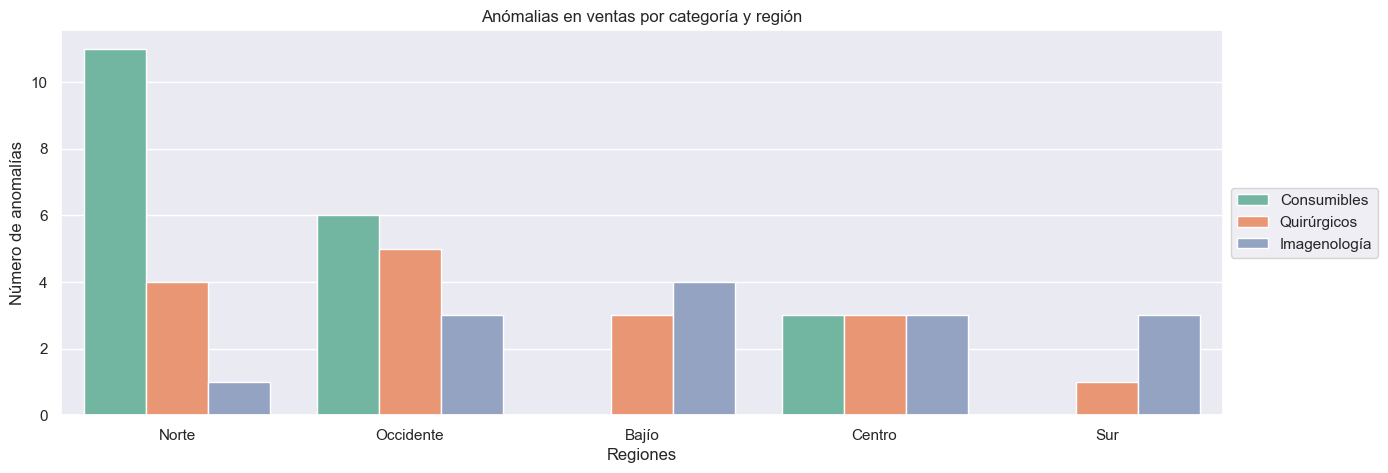

In [ ]:
plt.figure(figsize=(15,5))

sns.barplot(
    data = reporte_anomalias,
    x = 'Region',
    y = 'Num_Anomalias', 
    hue = 'Product_Category',
    palette='Set2'
)

plt.title("Anómalias en ventas por categoría y región")
plt.xlabel("Regiones")
plt.ylabel('Número de anomalías')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Inicialmente se evaluó la detección de anomalías mediante Z-Score global, resultando en un falso positivo del 97% del dataset. Esto confirmó matemáticamente la naturaleza multimodal de los datos de MedTech, donde la media global no es representativa.

Se pivotó hacia un enfoque de IQR Segmentado por Categoría, logrando identificar con precisión 53 anomalías críticas (errores de captura y outliers de negocio), permitiendo una limpieza efectiva sin comprometer la integridad de los datos de volumen

In [28]:
# Análisis de satisfacción de clientes 

median_satisfaction = df_clean['Customer_Satisfaction'].median()
df_clean['Customer_Satisfaction'] = df_clean['Customer_Satisfaction'].fillna(median_satisfaction)
df_clean.isnull().sum()

Order_ID                 0
Date                     0
Hospital_Type            0
Region                   0
Product_Category         0
Product_Name             0
Quantity                 0
Unit_Price_USD           0
Discount_Applied         0
Total_Sales_USD          0
Customer_Satisfaction    0
Business_unit            0
dtype: int64

In [30]:
df_clean['Customer_Satisfaction'].describe()

count    4992.000000
mean        7.942989
std         1.246007
min         2.600000
25%         7.300000
50%         8.000000
75%         8.700000
max        10.000000
Name: Customer_Satisfaction, dtype: float64

In [ ]:
# Segmentación por equipos de imagenología 

df_images = df_clean[df_clean['Product_Category']== 'Imagenología']

# estratificación 

bins = [0,4,7,10]
labels = ['Baja', 'Media', 'Alta']
df_images['Sat_Category'] = pd.cut(
    df_images['Customer_Satisfaction'], 
    bins = bins, 
    labels = labels 
)

print("Distribución de satisfacción en Imagenología:")
sat_category_count = df_images['Sat_Category'].value_counts().reset_index()
print(sat_category_count)

Distribución de satisfacción en Imagenología:
  Sat_Category  count
0         Alta    397
1        Media    102
2         Baja      2


In [50]:
fig = px.pie(
    sat_category_count, 
    values = 'count',
    names = 'Sat_Category',
    title = 'Porcentajes de satisfacción de clientes de equipos de imagenología'
)

fig.show()

<Figure size 1500x500 with 0 Axes>

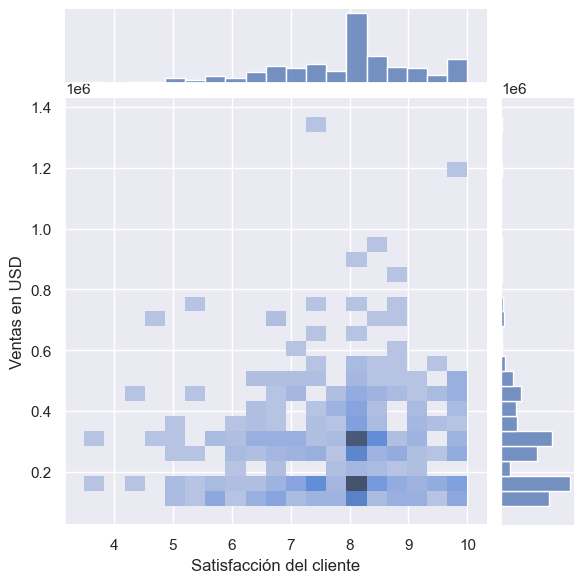

In [101]:
# Gráf de dispersión para ver la relación entre satisfacción y número de compras 

plt.figure(figsize=(15,5))
sns.jointplot(
    data = df_images,
    x = 'Customer_Satisfaction', 
    y= 'Total_Sales_USD',
    kind = 'hist'
)

plt.xlabel('Satisfacción del cliente')
plt.ylabel('Ventas en USD')


plt.show()


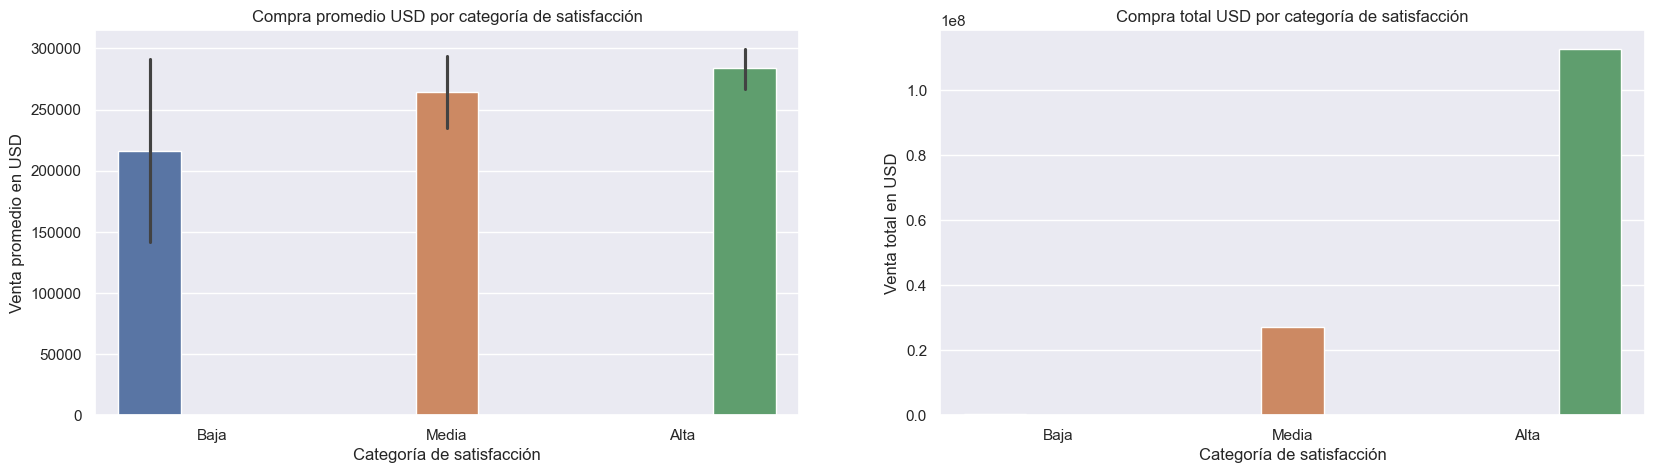

In [107]:

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,5))

sns.barplot(
    data = df_images, 
    x = 'Sat_Category', 
    y= 'Total_Sales_USD', 
    estimator = 'mean',
    ax = ax1,
    hue = 'Sat_Category',
)

ax1.set_title('Compra promedio USD por categoría de satisfacción')
ax1.set_xlabel('Categoría de satisfacción')
ax1.set_ylabel('Venta promedio en USD')

sns.barplot(
    data = df_images, 
    x = 'Sat_Category', 
    y= 'Total_Sales_USD', 
    estimator = 'sum',
    ax = ax2,
    hue = 'Sat_Category',
    errorbar = None
)

ax2.set_title('Compra total USD por categoría de satisfacción')
ax2.set_xlabel('Categoría de satisfacción')
ax2.set_ylabel('Venta total en USD')

plt.show()

In [114]:
# ANOVA para determinar diferencia estadística significativa entre las categorías de satisfacción

cat_baja = df_images[df_images['Sat_Category'] == 'Baja']['Total_Sales_USD']
cat_media = df_images[df_images['Sat_Category'] == 'Media']['Total_Sales_USD']
cat_alta = df_images[df_images['Sat_Category'] == 'Alta']['Total_Sales_USD']

f_stat, p_value_anova = stats.f_oneway(cat_baja, cat_media, cat_alta)

print(f"Resultados ANOVA para Imagenología:")
print(f"Estadístico F: {f_stat:.2f}")
print(f"P-value: {p_value_anova:.2f}")


Resultados ANOVA para Imagenología:
Estadístico F: 0.78
P-value: 0.46


In [110]:
tukey = pairwise_tukeyhsd(
    endog= df_images['Total_Sales_USD'], 
    groups= df_images['Sat_Category'], 
    alpha = 0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
  Alta   Baja -67591.0343 0.8206 -332793.5207 197611.4522  False
  Alta  Media -19690.4465 0.5055  -61219.9107  21839.0177  False
  Baja  Media  47900.5877 0.9067 -219217.3055  315018.481  False
----------------------------------------------------------------


In [111]:
gh_test = pg.pairwise_gameshowell(
    data = df_images, 
    dv = 'Total_Sales_USD', 
    between = 'Sat_Category'
)

print(gh_test)

       A      B         mean_A         mean_B          diff            se  \
0   Baja  Media  216405.890000  264306.477745 -47900.587745  76356.115299   
1   Baja   Alta  216405.890000  283996.924257 -67591.034257  75377.396290   
2  Media   Alta  264306.477745  283996.924257 -19690.446512  16753.997951   

          T          df      pval    hedges  
0 -0.627331    1.077874  0.833537 -0.322145  
1 -0.896702    1.023678  0.727101 -0.416771  
2 -1.175269  168.714150  0.469569 -0.123469  


In [119]:
# Correlación de Spearman para datos categorícos 

x = df_images['Customer_Satisfaction']
y = df_images['Total_Sales_USD']

coef_rho, p_value_spearman = stats.spearmanr(x,y)

print("--- Análisis de correlación de Spearman ---")
print(f"Coeficiente Rho (ρ): {coef_rho:.2f}")
print(f"P-Value: {p_value_spearman:.2e}")


if p_value_spearman < 0.05:
    print("\nConclusión: Existe una relación  significativa.")
    if coef_rho > 0:
        print("A mayor satisfacción, mayor tendencia de ventas (Relación Positiva).")
    else:
        print("A mayor satisfacción, menor tendencia de ventas (Relación Negativa).")
else:
    print("\nConclusión: No hay evidencia de relación significativa (p > 0.05).")

--- Análisis de correlación de Spearman ---
Coeficiente Rho (ρ): 0.07
P-Value: 1.08e-01

Conclusión: No hay evidencia de relación significativa (p > 0.05).


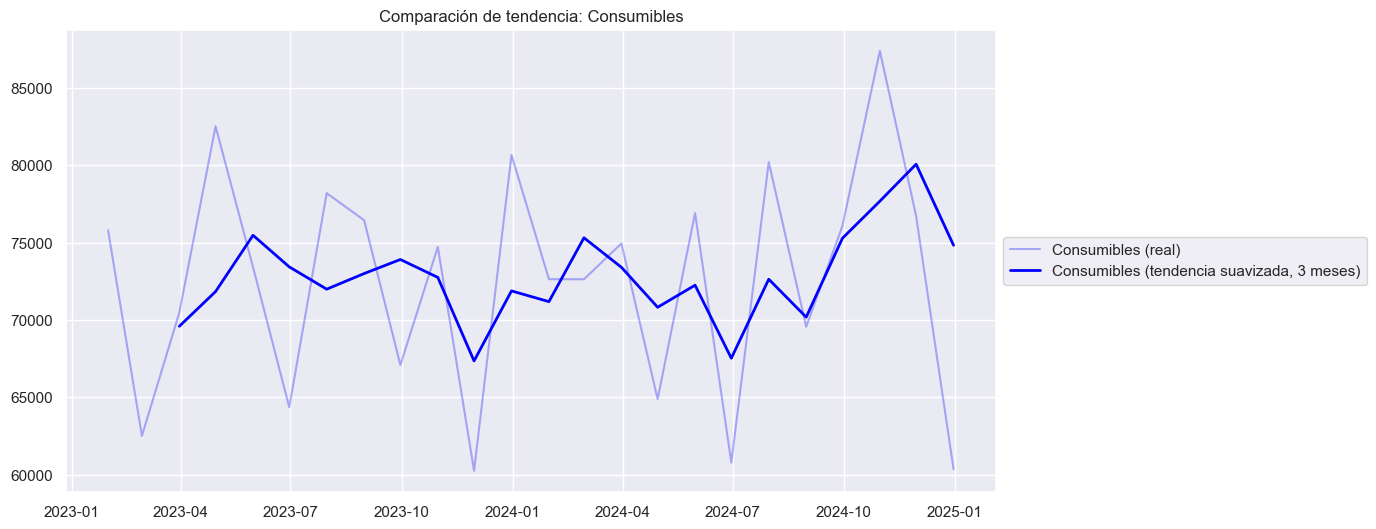

In [129]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_ts = df_clean.set_index('Date')

consumibles_monthly = df_ts[df_ts['Product_Category'] == 'Consumibles']['Quantity'].resample('ME').sum()



consumibles_ma = consumibles_monthly.rolling(window = 3).mean()



plt.figure(figsize=(12, 6))
plt.plot(consumibles_monthly, label='Consumibles (real)', alpha=0.3, color='blue')
plt.plot(consumibles_ma, label='Consumibles (tendencia suavizada, 3 meses)', color='blue', linewidth=2)
plt.title('Comparación de tendencia: Consumibles')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

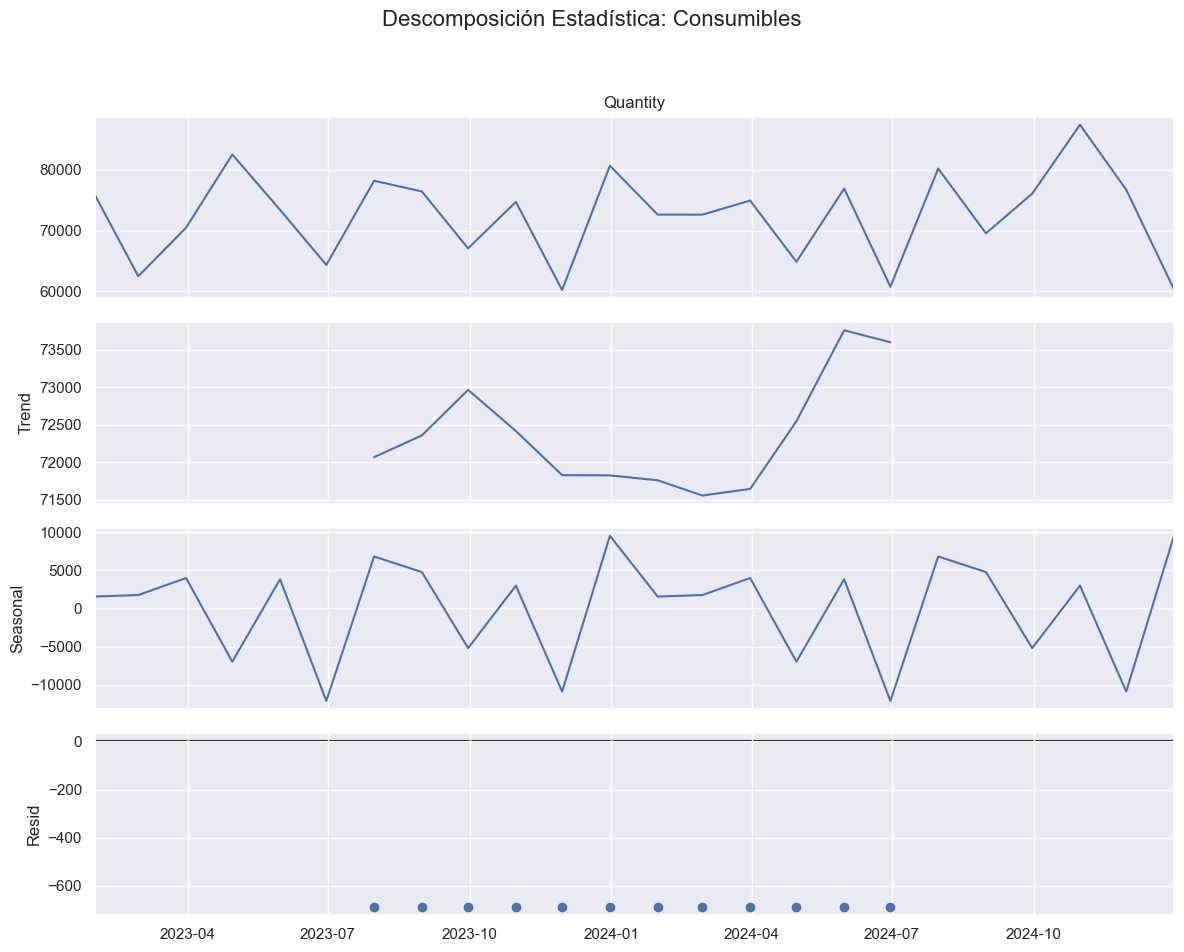

In [130]:
# Descomposición estadística 

decomposition = seasonal_decompose(consumibles_monthly, model='additive', period = 12)

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Descomposición Estadística: Consumibles', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

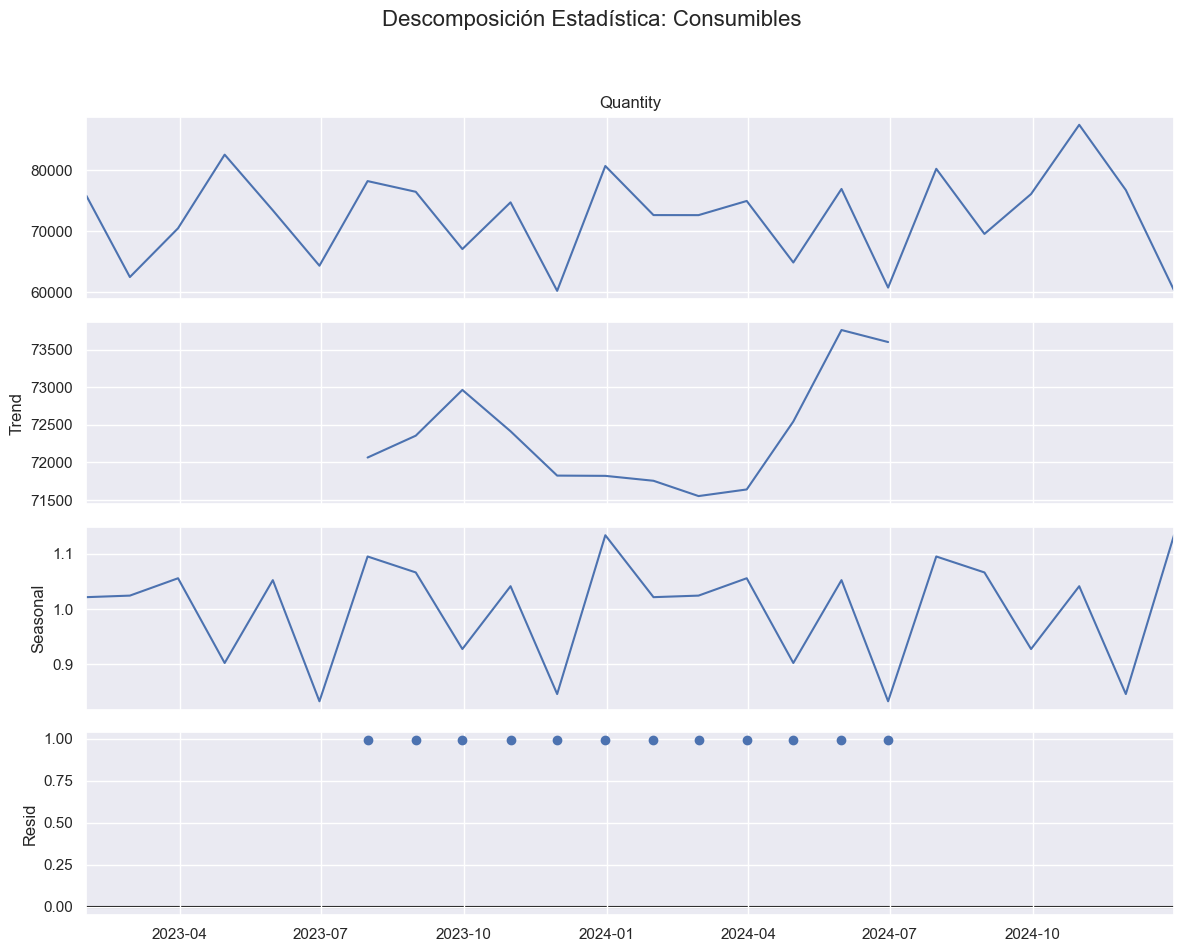

In [131]:

decomposition = seasonal_decompose(consumibles_monthly, model='multiplicative', period = 12)

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Descomposición Estadística: Consumibles', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Generación de plan de compras de acuerdo al modelo aditivo de tendencia 

def generar_plan_compras(df, index_name = 'Date', cat_name = None, ):

    df['Date'] = pd.to_datetime(df['Date'])
    df_ts = df.set_index('Date')

    consumibles_monthly = df_ts[df_ts['Product_Category'] == 'Consumibles']['Quantity'].resample('ME').sum()
    consumibles_ma = consumibles_monthly.rolling(window=3).mean()

    decomposition = seasonal_decompose(consumibles_monthly, model='additive', period=12)

    trend = decomposition.trend
    seasonal = decomposition.seasonal
    resid = decomposition.resid


    std_resid = resid.std(skipna=True)
    safety_stock = std_resid * 2 if not np.isnan(std_resid) else 0

    df_plan = pd.DataFrame({
        'Tendencia_Base': trend,
        'Efecto_Estacional': seasonal,
        'Demanda_Esperada': trend + seasonal
    }).dropna() 
    

    df_plan['Stock_Seguridad'] = round(safety_stock, 0)
    df_plan['Sugerencia_Compra_Total'] = round(df_plan['Demanda_Esperada'] + safety_stock, 0)
    
  
    df_plan.index.name = 'Mes_Proyectado'

    df_plan.sort_index(ascending=True, inplace=True)
    df_plan['Mes_Nombre'] = df_plan.index.strftime('%B %Y')
    cols = ['Mes_Nombre', 'Tendencia_Base', 'Efecto_Estacional', 'Demanda_Esperada', 'Stock_Seguridad', 'Sugerencia_Compra_Total']
    df_plan = df_plan[cols]
    
    print(f"Plan de abastecimiento optimizado para consumibles")
    return df_plan



In [146]:
generar_plan_compras(df_clean)

Plan de abastecimiento optimizado para consumibles


,Mes_Nombre,Tendencia_Base,Efecto_Estacional,Demanda_Esperada,Stock_Seguridad,Sugerencia_Compra_Total
Mes_Proyectado,,,,,,
2023-07-31,July 2023,72065.708333,6808.559028,78874.267361,0.0,78874.0
2023-08-31,August 2023,72355.958333,4768.309028,77124.267361,0.0,77124.0
2023-09-30,September 2023,72963.625000,-5200.357639,67763.267361,0.0,67763.0
2023-10-31,October 2023,72414.875000,2987.392361,75402.267361,0.0,75402.0
2023-11-30,November 2023,71825.875000,-10895.607639,60930.267361,0.0,60930.0
2023-12-31,December 2023,71822.500000,9519.767361,81342.267361,0.0,81342.0
2024-01-31,January 2024,71757.208333,1559.059028,73316.267361,0.0,73316.0
2024-02-29,February 2024,71554.041667,1755.225694,73309.267361,0.0,73309.0
2024-03-31,March 2024,71641.916667,3982.350694,75624.267361,0.0,75624.0
